<a href="https://colab.research.google.com/github/Felixe360/BI-leaders/blob/main/naieve_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the dataset from "/content/carclaims.csv", inspect the columns to identify the correct target variable, and preprocess the data by handling missing values and applying one-hot encoding. Train and tune Bernoulli Naive Bayes models by varying `alpha`, `fit_prior`, and `binarize` thresholds. Finally, analyze and visualize the performance metrics to evaluate the best model and summarize the findings.

## Inspect Dataset Columns

### Subtask:
Load the dataset and inspect the columns to identify the target variable.


**Reasoning**:
Import pandas, load the dataset from '/content/carclaims.csv', print the column names to identify the correct target variable, and display the first few rows to understand the data structure.



In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/carclaims.csv')

# Print the list of column names to identify the target variable
print("Columns:", df.columns.tolist())

# Display the first few rows of the DataFrame
print(df.head())

Columns: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year', 'BasePolicy', 'FraudFound']
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthCla

## Update Data Preprocessing

### Subtask:
Preprocess the `carclaims` dataset by handling missing values, encoding the target variable `FraudFound`, and splitting the data.


**Reasoning**:
Perform the preprocessing steps including handling missing values, dropping the ID column, encoding the target and categorical features, and splitting the data into training and testing sets.



In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Replace '?' with NaN and drop rows with missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# 2. Drop 'PolicyNumber' column
if 'PolicyNumber' in df.columns:
    df.drop(columns=['PolicyNumber'], inplace=True)

# 3. Convert target 'FraudFound' to 1/0
# 'Yes' becomes 1, 'No' becomes 0
df['FraudFound'] = df['FraudFound'].map({'Yes': 1, 'No': 0})

# 4. Apply One-Hot Encoding to categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# 5. Define features (X) and target (y)
X = df_encoded.drop('FraudFound', axis=1)
y = df_encoded['FraudFound']

# 6. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



**Reasoning**:
The previous code block failed due to a `SyntaxError` caused by an incomplete `print` statement. I will correct this by completing the `print` statement to correctly display the shapes of the training and testing sets.



In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Replace '?' with NaN and drop rows with missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# 2. Drop 'PolicyNumber' column
if 'PolicyNumber' in df.columns:
    df.drop(columns=['PolicyNumber'], inplace=True)

# 3. Convert target 'FraudFound' to 1/0
# 'Yes' becomes 1, 'No' becomes 0
if df['FraudFound'].dtype == 'object':
    df['FraudFound'] = df['FraudFound'].map({'Yes': 1, 'No': 0})

# 4. Apply One-Hot Encoding to categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# 5. Define features (X) and target (y)
X = df_encoded.drop('FraudFound', axis=1)
y = df_encoded['FraudFound']

# 6. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Print the shapes of the training and testing sets
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (12336, 123)
Testing set shape: (3084, 123)


## Re-run Hyperparameter Tuning

### Subtask:
Train Bernoulli Naive Bayes models with various hyperparameters and record performance metrics.


**Reasoning**:
Implement the hyperparameter tuning loop for Bernoulli Naive Bayes as specified in the instructions. This involves importing necessary libraries, defining hyperparameter grids, iterating through combinations to train and evaluate models, and finally storing and identifying the best model based on F1-score.



In [13]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define hyperparameters
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
fit_priors = [True, False]
binarize_thresholds = [0.0, 0.5, 10.0, 50.0, 100.0, 500.0, 1000.0]

results = []

# Iterate through every combination of alpha, fit_prior, and binarize threshold
for alpha in alphas:
    for fit_prior in fit_priors:
        for binarize in binarize_thresholds:
            # Instantiate and fit model
            model = BernoulliNB(alpha=alpha, fit_prior=fit_prior, binarize=binarize)
            model.fit(X_train, y_train)

            # Predict on test set
            y_pred = model.predict(X_test)

            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            results.append({
                'alpha': alpha,
                'fit_prior': fit_prior,
                'binarize': binarize,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1_score': f1
            })

# Create DataFrame
results_df = pd.DataFrame(results)

# Display the first few rows of results_df
print("First 5 rows of results:")
print(results_df.head())

# Identify and print the parameters and metrics of the best model based on the highest F1-score
best_idx = results_df['f1_score'].idxmax()
best_model = results_df.loc[best_idx]
print("\nBest Model Parameters (highest F1-score):")
print(best_model)

First 5 rows of results:
   alpha  fit_prior  binarize  accuracy  precision    recall  f1_score
0   0.01       True       0.0  0.916018   0.183673  0.091371  0.122034
1   0.01       True       0.5  0.916018   0.183673  0.091371  0.122034
2   0.01       True      10.0  0.936122   0.000000  0.000000  0.000000
3   0.01       True      50.0  0.936122   0.000000  0.000000  0.000000
4   0.01       True     100.0  0.936122   0.000000  0.000000  0.000000

Best Model Parameters (highest F1-score):
alpha            10.0
fit_prior       False
binarize          0.0
accuracy     0.640402
precision    0.135783
recall       0.862944
f1_score     0.234645
Name: 77, dtype: object


## Re-run Visualization and Evaluation

### Subtask:
Visualize the impact of hyperparameters and evaluate the best model on the test set.


**Reasoning**:
I will generate a code block to visualize the performance metrics against hyperparameters and evaluate the best Bernoulli Naive Bayes model using the test set, as per the instructions.



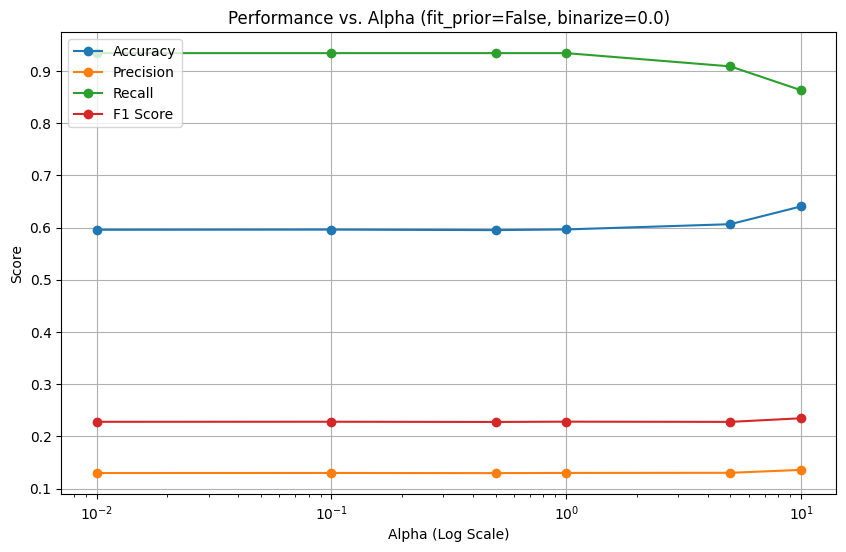

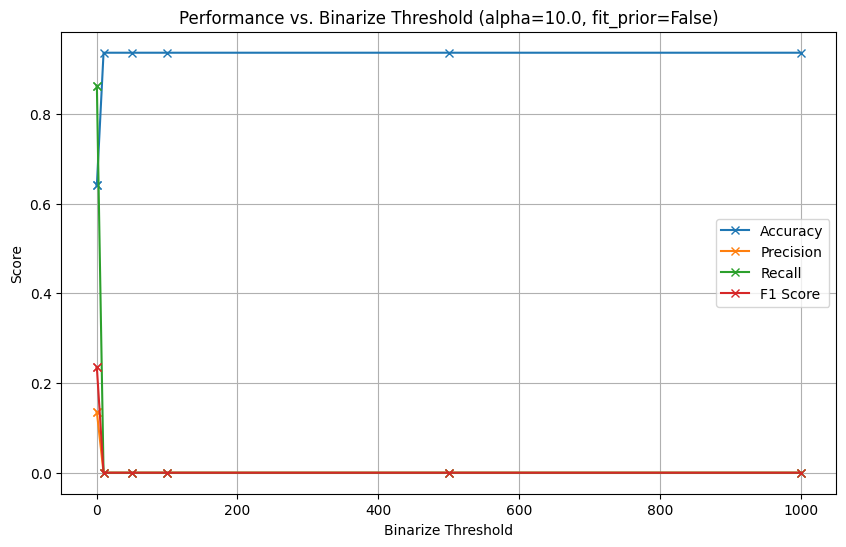

Final Model Evaluation Report:
              precision    recall  f1-score   support

           0       0.99      0.63      0.76      2887
           1       0.14      0.86      0.23       197

    accuracy                           0.64      3084
   macro avg       0.56      0.74      0.50      3084
weighted avg       0.93      0.64      0.73      3084



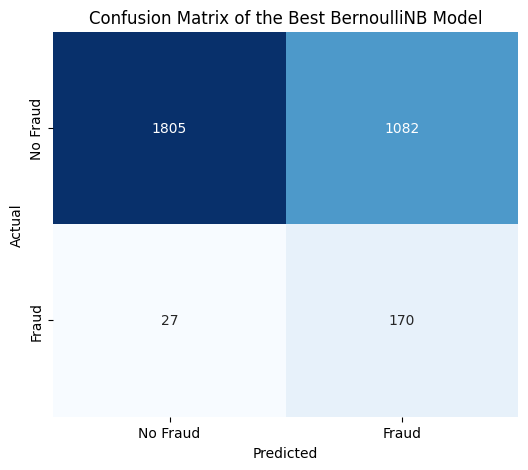

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.naive_bayes import BernoulliNB

# 1. Visualize Performance vs. Alpha
# Filter for fit_prior=False and binarize=0.0 (based on best model analysis)
subset_alpha = results_df[(results_df['fit_prior'] == False) & (results_df['binarize'] == 0.0)]

plt.figure(figsize=(10, 6))
plt.plot(subset_alpha['alpha'], subset_alpha['accuracy'], marker='o', label='Accuracy')
plt.plot(subset_alpha['alpha'], subset_alpha['precision'], marker='o', label='Precision')
plt.plot(subset_alpha['alpha'], subset_alpha['recall'], marker='o', label='Recall')
plt.plot(subset_alpha['alpha'], subset_alpha['f1_score'], marker='o', label='F1 Score')

plt.xscale('log')
plt.title('Performance vs. Alpha (fit_prior=False, binarize=0.0)')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# 2. Visualize Performance vs. Binarize Threshold
# Filter for alpha=10.0 and fit_prior=False
subset_bin = results_df[(results_df['alpha'] == 10.0) & (results_df['fit_prior'] == False)]

plt.figure(figsize=(10, 6))
plt.plot(subset_bin['binarize'], subset_bin['accuracy'], marker='x', label='Accuracy')
plt.plot(subset_bin['binarize'], subset_bin['precision'], marker='x', label='Precision')
plt.plot(subset_bin['binarize'], subset_bin['recall'], marker='x', label='Recall')
plt.plot(subset_bin['binarize'], subset_bin['f1_score'], marker='x', label='F1 Score')

plt.title('Performance vs. Binarize Threshold (alpha=10.0, fit_prior=False)')
plt.xlabel('Binarize Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# 3. Final Model Evaluation
# Retrain with best parameters: alpha=10.0, fit_prior=False, binarize=0.0
best_alpha = 10.0
best_fit_prior = False
best_binarize = 0.0

final_model = BernoulliNB(alpha=best_alpha, fit_prior=best_fit_prior, binarize=best_binarize)
final_model.fit(X_train, y_train)
final_y_pred = final_model.predict(X_test)

print("Final Model Evaluation Report:")
print(classification_report(y_test, final_y_pred))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the Best BernoulliNB Model')
plt.show()

# Task
Generate a bar plot comparing model performance metrics for `fit_prior=True` vs `fit_prior=False`, specifically setting `alpha=10.0` and `binarize=0.0` using the tuning results from the "/content/carclaims.csv" dataset analysis. Finally, interpret the fit_prior comparison plot.

## Plot fit_prior Comparison

### Subtask:
Generate a bar plot comparing performance metrics for fit_prior=True vs False with fixed alpha=10.0 and binarize=0.0.


**Reasoning**:
Filter the results for the specific alpha and binarize threshold, reshape the data using melt, and then create a grouped bar plot to compare the impact of the fit_prior parameter.



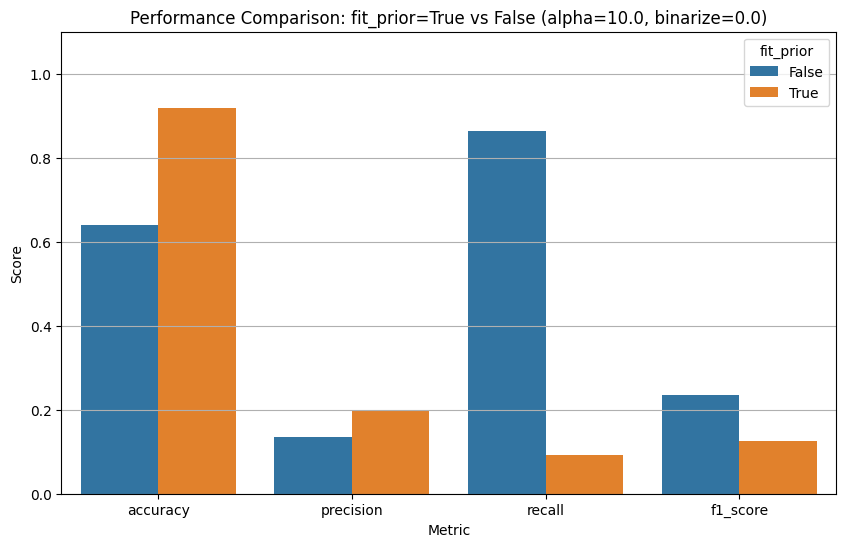

In [15]:
subset_prior = results_df[(results_df['alpha'] == 10.0) & (results_df['binarize'] == 0.0)]

# Melt the DataFrame for plotting
subset_prior_melt = subset_prior.melt(
    id_vars=['fit_prior'],
    value_vars=['accuracy', 'precision', 'recall', 'f1_score'],
    var_name='Metric',
    value_name='Score'
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=subset_prior_melt, x='Metric', y='Score', hue='fit_prior')

plt.title('Performance Comparison: fit_prior=True vs False (alpha=10.0, binarize=0.0)')
plt.ylim(0, 1.1)  # Set y-axis limit to accommodate scores up to 1.0
plt.grid(axis='y')
plt.show()